In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.calibration import calibration_curve

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
from euroqol.utils import fit_classifiers, compute_weights, run_calibration_diagnostics, compute_smd

In [4]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse_1718   = df[df["dataset"].isin(["HSE 2017", "HSE 2018"])].copy()
daphnie_24 = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"HSE 2017–2018: n = {len(hse_1718):,}")
print(f"DAPHNIE 2024:  n = {len(daphnie_24):,}")
print(f"Class ratio    DAPHNIE:HSE = 1:{len(hse_1718)/len(daphnie_24):.1f}")

HSE 2017–2018: n = 15,830
DAPHNIE 2024:  n = 5,237
Class ratio    DAPHNIE:HSE = 1:3.0


## Density Ratio Estimation — DAPHNIE 2020 and HSE2017-2018

### Rationale

This notebook is the definitive density ratio estimation for the norm derivation
pipeline. It differs from notebook 03 in three ways:

- **Source:** DAPHNIE 2024 only. DAPHNIE 2023 is a pilot with anomalous employment
  composition and is excluded from norm derivation.
- **Target:** HSE 2017–2018 only (n ≈ 16,173). HSE 2019 is excluded because it has
  no EQ-5D-5L outcome data. Notebook 011 confirmed HSE 2017 and 2018 are consistent.
- **Predictor set:** 17 variables — the 13-variable notebook 03 set extended with
  `resp`, `skin`, `PA_vig`, and `PA_mod`, all 0% missing in HSE 2017–18 and DAPHNIE
  2024 once HSE 2019 is excluded. `alcohol_yr` is excluded from the model
  (skip-logic artefact) but appears in the balance check as a diagnostic.

The density ratio weights produced here are the ones used in notebook 04 for
importance-weighted norm derivation. Notebook 03 weights are **not** reusable — the
target distribution has changed.

The classifier architecture and calibration strategy are identical to notebook 03:
six variants (LR, LR+Platt, LR+Venn-Abers, HGB, HGB+Isotonic, HGB+Venn-Abers),
all with `class_weight='balanced'` so that $w(x) = \hat{p}/(1-\hat{p})$ holds
without sample-size correction.

In [5]:
# 17-variable predictor set divided into "base" and "extra" features 
# for later analysis of the contribution of the extra features to covariate shift correction.
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)


Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


In [6]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

n_src, n_tgt = len(daphnie_24), len(hse_1718)
print(f"DAPHNIE 2024 (n={n_src:,}) vs HSE 2017–2018 (n={n_tgt:,})")
print(f"Class ratio DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")

models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_24, hse_1718, ALL_FEATURES)

print(f"\nBase model AUC (5-fold CV):")
print(f"  LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
print(f"  HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

X_daphnie = daphnie_24[ALL_FEATURES]
weights = {}
print(f"\nImportance weight diagnostics (99th-pct clip):")
print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
for name, clf in models.items():
    w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
    weights[name] = w
    print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
          f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

DAPHNIE 2024 (n=5,237) vs HSE 2017–2018 (n=15,830)
Class ratio DAPHNIE:HSE = 1:3.0

Base model AUC (5-fold CV):
  LR  : 0.732  (± 0.009)
  HGB : 0.868  (± 0.009)

Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           5.09     52 (1.0%)    2966/5237 (56.6%)
  LR + Platt                   4.26     52 (1.0%)    3356/5237 (64.1%)
  LR + Venn-Abers              6.65     52 (1.0%)    2375/5237 (45.4%)
  HGB                          9.59     53 (1.0%)    1401/5237 (26.8%)
  HGB + Isotonic               9.08     51 (1.0%)    1542/5237 (29.4%)
  HGB + Venn-Abers             9.45     53 (1.0%)    1464/5237 (28.0%)


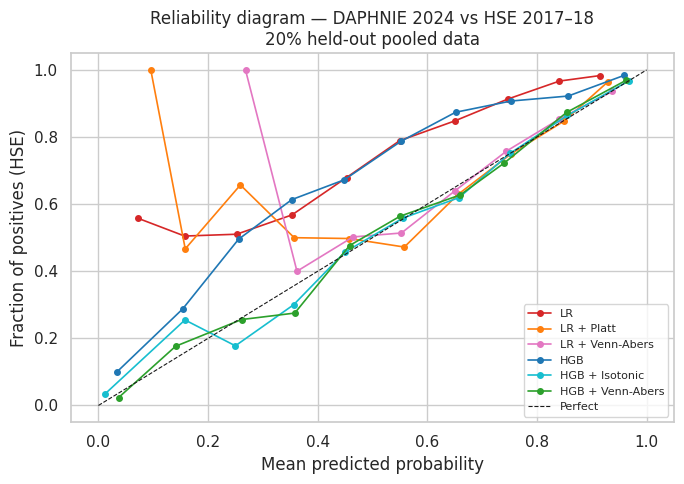


Calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.213,0.215
LR + Platt,0.166,0.027
LR + Venn-Abers,0.164,0.015
HGB,0.148,0.138
HGB + Isotonic,0.120,0.011
HGB + Venn-Abers,0.122,0.017


In [7]:
probs, y_cal, cal_metrics = run_calibration_diagnostics(daphnie_24, hse_1718, ALL_FEATURES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probs.items():
    frac, mean_pred = calibration_curve(y_cal, p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
            label=name, color=MODEL_COLORS[name])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
ax.set_title("Reliability diagram — DAPHNIE 2024 vs HSE 2017–18\n20% held-out pooled data")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (HSE)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability_DAPHNIE24_vs_HSE1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

print("\nCalibration metrics (held-out 20%):")
display(cal_metrics.round(4))

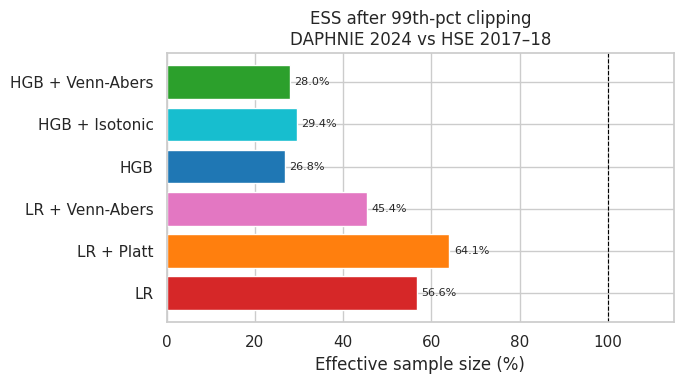

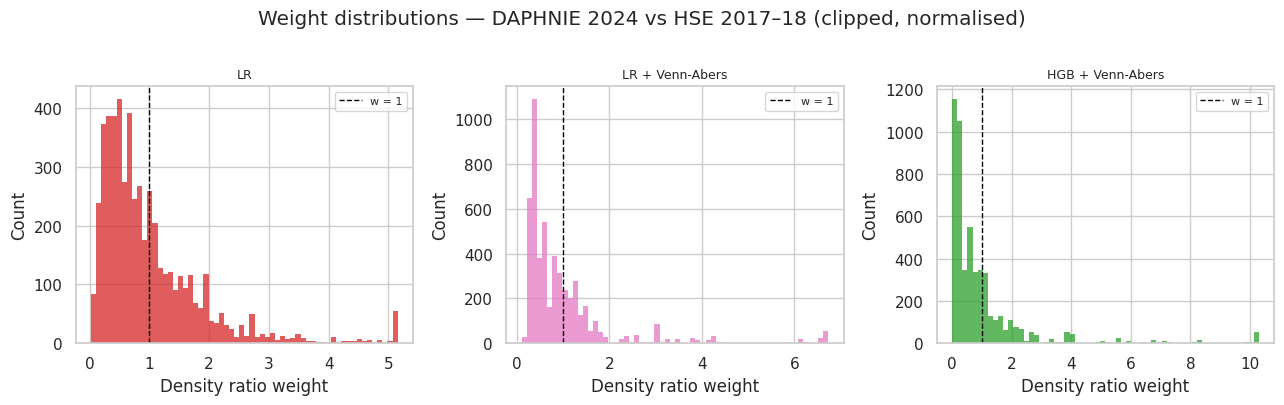

In [8]:
# ESS comparison across all six models
names    = list(weights.keys())
ess_pct  = [weights[n].sum()**2 / (weights[n]**2).sum() / n_src * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effective sample size (%)")
ax.set_title("ESS after 99th-pct clipping\nDAPHNIE 2024 vs HSE 2017–18")
ax.set_xlim(0, 115)
for i, v in enumerate(ess_pct):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison__DAPHNIE24_vs_HSE1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Weight distributions — LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, KEY_DIST):
    w = weights[name]
    ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Density ratio weight")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Weight distributions — DAPHNIE 2024 vs HSE 2017–18 (clipped, normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions_DAPHNIE24_vs_HSE1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

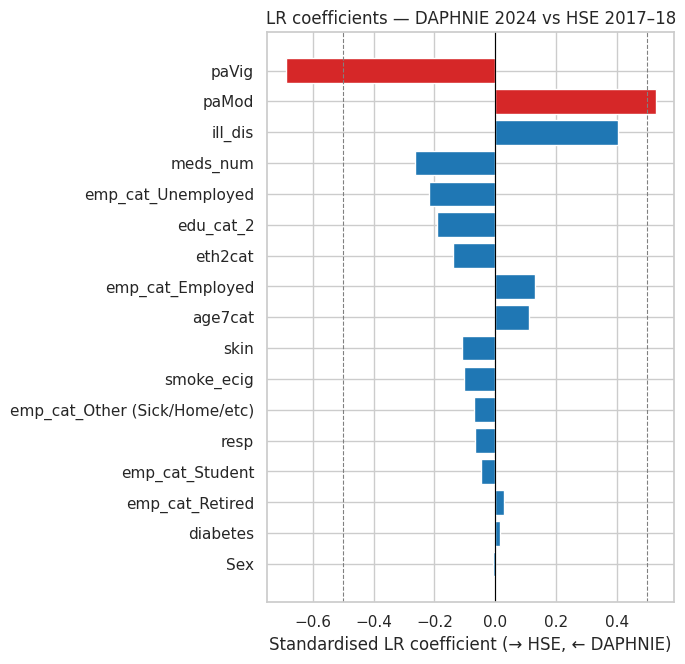

LR coefficients (standardised):


,coefficient,|coefficient|
paVig,-0.689,0.689
paMod,0.528,0.528
ill_dis,0.405,0.405
meds_num,-0.264,0.264
emp_cat_Unemployed,-0.216,0.216
edu_cat_2,-0.191,0.191
eth2cat,-0.140,0.140
emp_cat_Employed,0.131,0.131
age7cat,0.111,0.111
skin,-0.108,0.108


In [9]:
# LR coefficient inspection
# Use X.columns (features the model was actually fitted on) rather than FEATURES,
# so this cell is safe to run even if FEATURES was redefined after fitting.
clf       = models["LR"].named_steps["clf"]
fit_feats = X.columns.tolist()
coef      = pd.Series(clf.coef_[0], index=fit_feats).sort_values(key=abs)
colors    = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]

fig, ax = plt.subplots(figsize=(7, max(5, len(fit_feats) * 0.4)))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")
ax.set_title("LR coefficients — DAPHNIE 2024 vs HSE 2017–18")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients_DAPHNIE24_vs_HSE1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

tbl = (
    pd.DataFrame({
        "coefficient":   clf.coef_[0],
        "|coefficient|": np.abs(clf.coef_[0]),
    }, index=fit_feats)
    .sort_values("|coefficient|", ascending=False)
)
print("LR coefficients (standardised):")
display(tbl.round(3))

In [10]:
# Balance check: FEATURES + alcohol_yr as diagnostic
# alcohol_yr is not in the model but included here to show whether the
# skip-logic imbalance is incidentally corrected or worsened by the weights.
BALANCE_VARS = ALL_FEATURES
KEY_BALANCE  = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = hse_1718["wt_int"].fillna(1.0)
svy_wt = daphnie_24["svy_wt"].fillna(1.0)

smds = {}
for col in BALANCE_VARS:
    row = {"Before": compute_smd(daphnie_24[col], svy_wt, hse_1718[col], hse_wt)}
    for name in KEY_BALANCE:
        w = weights[name]
        row[f"After: {name}"] = compute_smd(daphnie_24[col], svy_wt * w, hse_1718[col], hse_wt)
    smds[col] = row

balance = pd.DataFrame(smds).T

print("Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:")
display(
    balance.dropna(how="all")
    .sort_values("Before", key=abs, ascending=False)
    .round(3)
)

Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
paVig,0.449,0.032,0.002,-0.015,0.013
edu_cat_2,0.237,-0.025,-0.051,0.001,-0.015
emp_cat_Unemployed,0.228,-0.005,0.011,-0.008,0.018
eth2cat,0.223,-0.045,-0.055,-0.112,-0.082
age7cat,-0.202,0.060,0.077,0.178,0.156
ill_dis,-0.174,0.117,0.153,0.096,0.099
paMod,-0.162,-0.065,-0.025,-0.105,-0.121
emp_cat_Student,0.118,-0.010,-0.005,-0.069,-0.041
emp_cat_Employed,-0.116,-0.052,-0.062,-0.092,-0.104
smoke_ecig,0.109,-0.012,-0.005,-0.070,-0.030


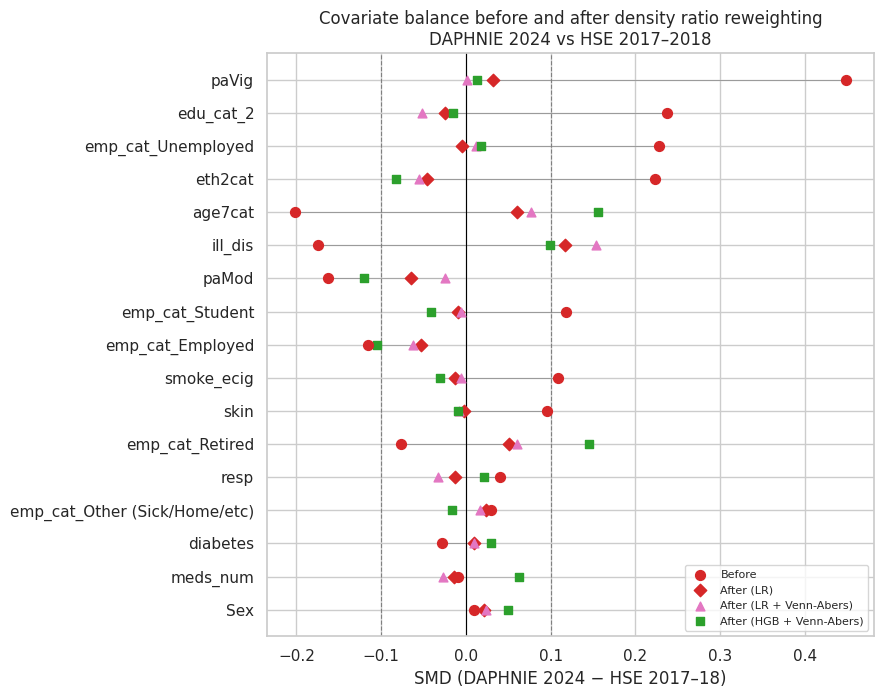

Balance on model features (17 variables):
  Before:              10 variables |SMD| > 0.1
  After (LR                    ): 1 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 1 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 4 variables |SMD| > 0.1


In [11]:
# Love plot — Before vs LR, LR+VA, HGB+VA
KEY_LOVE     = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

tbl_plot = balance.dropna(subset=["Before"]).copy()
order    = tbl_plot["Before"].abs().sort_values().index
y_pos    = np.arange(len(order))
before   = tbl_plot.loc[order, "Before"]

fig, ax = plt.subplots(figsize=(9, max(6, len(order) * 0.42)))
ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

for name in KEY_LOVE:
    col   = f"After: {name}"
    after = tbl_plot.loc[order, col]
    ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
               marker=LOVE_MARKERS[name], label=f"After ({name})")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate balance before and after density ratio reweighting\nDAPHNIE 2024 vs HSE 2017–2018")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting__DAPHNIE24_vs_HSE1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Summary
model_vars = [c for c in balance.index if c != "alcohol_yr"]
print(f"Balance on model features ({len(model_vars)} variables):")
print(f"  Before:              {balance.loc[model_vars, 'Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
for name in KEY_LOVE:
    col = f"After: {name}"
    print(f"  After ({name:<22}): {balance.loc[model_vars, col].abs().gt(0.1).sum()} variables |SMD| > 0.1")
if "alcohol_yr" in balance.index:
    print(f"\nalcohol_yr (diagnostic only, not in model):")
    for col in ["Before"] + [f"After: {n}" for n in KEY_LOVE]:
        print(f"  {col:<35}: SMD = {balance.loc['alcohol_yr', col]:.3f}")

# Base Feature Analysis

In [12]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

n_src, n_tgt = len(daphnie_24), len(hse_1718)
print(f"DAPHNIE 2024 (n={n_src:,}) vs HSE 2017–2018 (n={n_tgt:,})")
print(f"Class ratio DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")

models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_24, hse_1718, BASE_FEATURES)

print(f"\nBase model AUC (5-fold CV):")
print(f"  LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
print(f"  HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

X_daphnie = daphnie_24[BASE_FEATURES]
weights = {}
print(f"\nImportance weight diagnostics (99th-pct clip):")
print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
for name, clf in models.items():
    w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
    weights[name] = w
    print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
          f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

DAPHNIE 2024 (n=5,237) vs HSE 2017–2018 (n=15,830)
Class ratio DAPHNIE:HSE = 1:3.0

Base model AUC (5-fold CV):
  LR  : 0.653  (± 0.011)
  HGB : 0.810  (± 0.011)

Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           3.02     53 (1.0%)    3956/5237 (75.5%)
  LR + Platt                   2.64     53 (1.0%)    4205/5237 (80.3%)
  LR + Venn-Abers              3.10     53 (1.0%)    3885/5237 (74.2%)
  HGB                         11.53     53 (1.0%)    1555/5237 (29.7%)
  HGB + Isotonic              12.46     44 (0.8%)    1550/5237 (29.6%)
  HGB + Venn-Abers            10.35     53 (1.0%)    1768/5237 (33.8%)


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


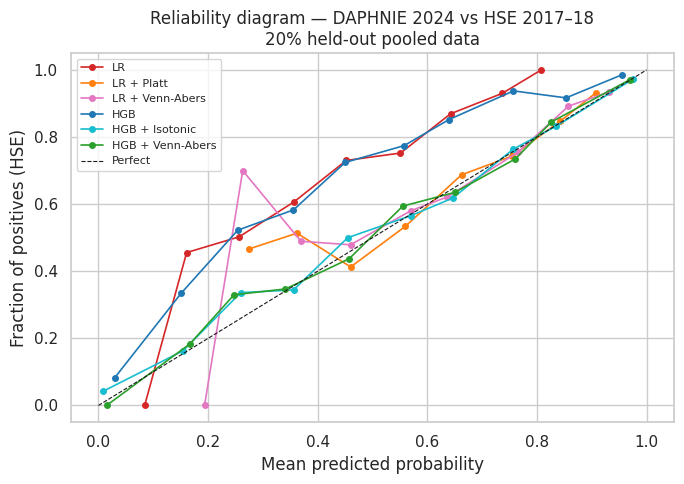


Calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.231,0.235
LR + Platt,0.175,0.016
LR + Venn-Abers,0.174,0.018
HGB,0.179,0.172
HGB + Isotonic,0.140,0.011
HGB + Venn-Abers,0.141,0.018


In [13]:
probs, y_cal, cal_metrics = run_calibration_diagnostics(daphnie_24, hse_1718, BASE_FEATURES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probs.items():
    frac, mean_pred = calibration_curve(y_cal, p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
            label=name, color=MODEL_COLORS[name])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
ax.set_title("Reliability diagram — DAPHNIE 2024 vs HSE 2017–18\n20% held-out pooled data")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (HSE)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability_DAPHNIE24_vs_HSE1718_all_features_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

print("\nCalibration metrics (held-out 20%):")
display(cal_metrics.round(4))

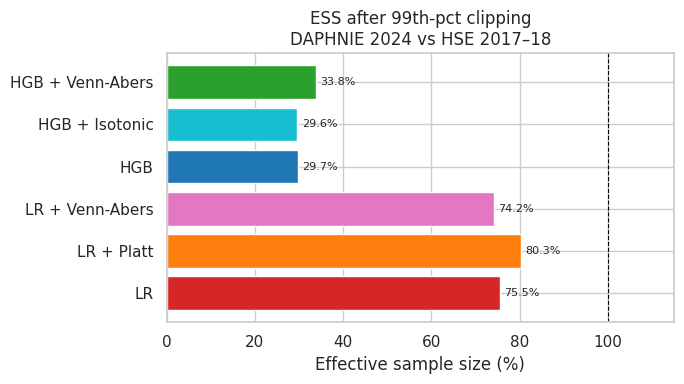

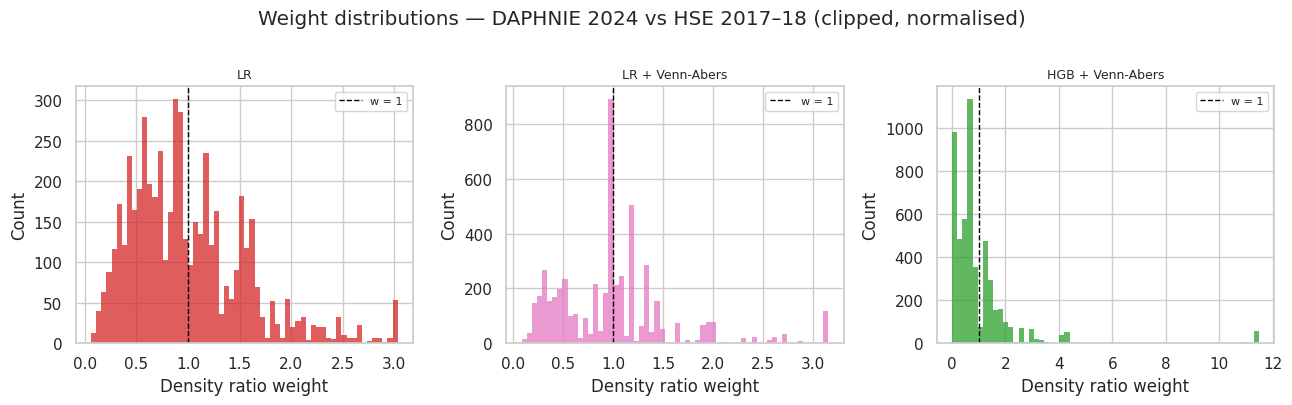

In [14]:
# ESS comparison across all six models
names    = list(weights.keys())
ess_pct  = [weights[n].sum()**2 / (weights[n]**2).sum() / n_src * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effective sample size (%)")
ax.set_title("ESS after 99th-pct clipping\nDAPHNIE 2024 vs HSE 2017–18")
ax.set_xlim(0, 115)
for i, v in enumerate(ess_pct):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison_DAPHNIE24_vs_HSE1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Weight distributions — LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, KEY_DIST):
    w = weights[name]
    ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Density ratio weight")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Weight distributions — DAPHNIE 2024 vs HSE 2017–18 (clipped, normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions_DAPHNIE24_vs_HSE1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

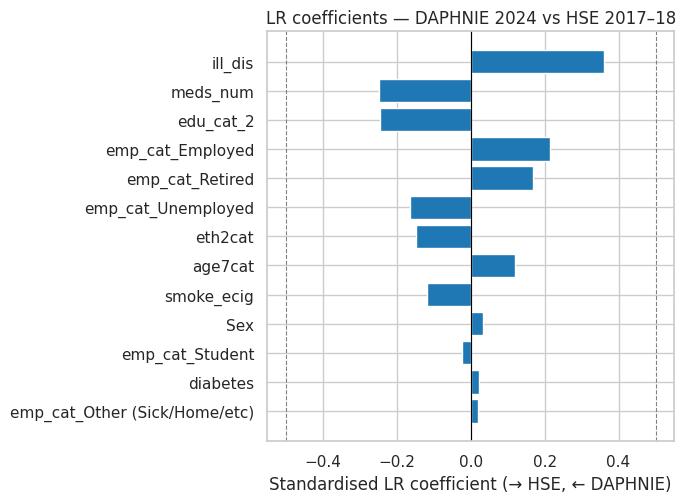

LR coefficients (standardised):


,coefficient,|coefficient|
ill_dis,0.361,0.361
meds_num,-0.249,0.249
edu_cat_2,-0.247,0.247
emp_cat_Employed,0.213,0.213
emp_cat_Retired,0.168,0.168
emp_cat_Unemployed,-0.163,0.163
eth2cat,-0.147,0.147
age7cat,0.119,0.119
smoke_ecig,-0.118,0.118
Sex,0.034,0.034


In [15]:
# LR coefficient inspection
# Use X.columns (features the model was actually fitted on) rather than FEATURES,
# so this cell is safe to run even if FEATURES was redefined after fitting.
clf       = models["LR"].named_steps["clf"]
fit_feats = X.columns.tolist()
coef      = pd.Series(clf.coef_[0], index=fit_feats).sort_values(key=abs)
colors    = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]

fig, ax = plt.subplots(figsize=(7, max(5, len(fit_feats) * 0.4)))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")
ax.set_title("LR coefficients — DAPHNIE 2024 vs HSE 2017–18")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients_DAPHNIE24_vs_HSE1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

tbl = (
    pd.DataFrame({
        "coefficient":   clf.coef_[0],
        "|coefficient|": np.abs(clf.coef_[0]),
    }, index=fit_feats)
    .sort_values("|coefficient|", ascending=False)
)
print("LR coefficients (standardised):")
display(tbl.round(3))

In [16]:
BALANCE_VARS = BASE_FEATURES
KEY_BALANCE  = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = hse_1718["wt_int"].fillna(1.0)
svy_wt = daphnie_24["svy_wt"].fillna(1.0)

smds = {}
for col in BALANCE_VARS:
    row = {"Before": compute_smd(daphnie_24[col], svy_wt, hse_1718[col], hse_wt)}
    for name in KEY_BALANCE:
        w = weights[name]
        row[f"After: {name}"] = compute_smd(daphnie_24[col], svy_wt * w, hse_1718[col], hse_wt)
    smds[col] = row

balance = pd.DataFrame(smds).T

print("Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:")
display(
    balance.dropna(how="all")
    .sort_values("Before", key=abs, ascending=False)
    .round(3)
)

Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2017–18:


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
edu_cat_2,0.237,-0.041,-0.036,0.000,-0.030
emp_cat_Unemployed,0.228,-0.011,-0.011,0.005,0.009
eth2cat,0.223,-0.053,-0.062,-0.084,-0.096
age7cat,-0.202,0.066,0.064,0.185,0.167
ill_dis,-0.174,0.095,0.107,0.124,0.122
emp_cat_Student,0.118,-0.036,-0.041,-0.073,-0.070
emp_cat_Employed,-0.116,-0.049,-0.049,-0.097,-0.113
smoke_ecig,0.109,-0.001,0.007,-0.050,-0.014
emp_cat_Retired,-0.076,0.059,0.062,0.132,0.149
emp_cat_Other (Sick/Home/etc),0.029,0.027,0.025,0.016,0.013


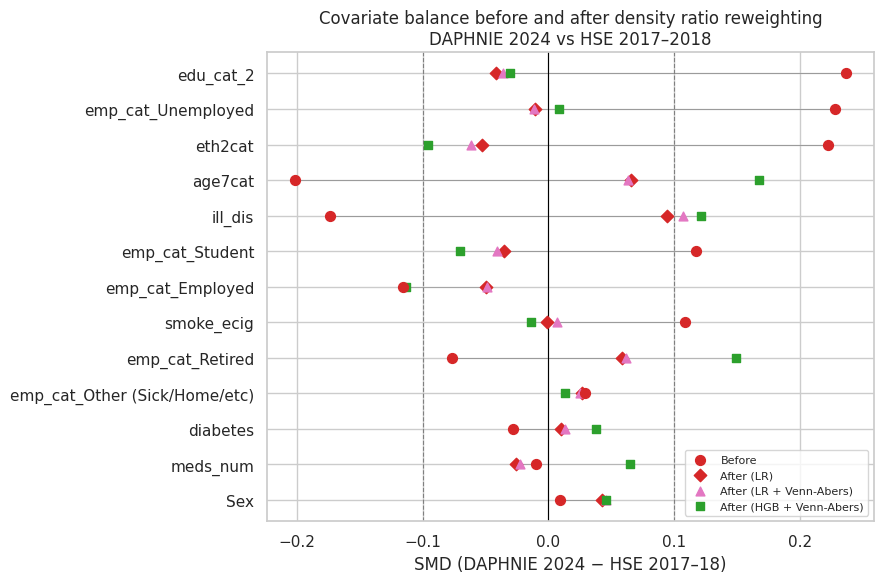

Balance on model features (13 variables):
  Before:              8 variables |SMD| > 0.1
  After (LR                    ): 0 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 1 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 4 variables |SMD| > 0.1


In [17]:
# Love plot — Before vs LR, LR+VA, HGB+VA
KEY_LOVE     = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

tbl_plot = balance.dropna(subset=["Before"]).copy()
order    = tbl_plot["Before"].abs().sort_values().index
y_pos    = np.arange(len(order))
before   = tbl_plot.loc[order, "Before"]

fig, ax = plt.subplots(figsize=(9, max(6, len(order) * 0.42)))
ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

for name in KEY_LOVE:
    col   = f"After: {name}"
    after = tbl_plot.loc[order, col]
    ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
               marker=LOVE_MARKERS[name], label=f"After ({name})")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate balance before and after density ratio reweighting\nDAPHNIE 2024 vs HSE 2017–2018")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting_DAPHNIE24_vs_HSE1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Summary
model_vars = [c for c in balance.index if c != "alcohol_yr"]
print(f"Balance on model features ({len(model_vars)} variables):")
print(f"  Before:              {balance.loc[model_vars, 'Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
for name in KEY_LOVE:
    col = f"After: {name}"
    print(f"  After ({name:<22}): {balance.loc[model_vars, col].abs().gt(0.1).sum()} variables |SMD| > 0.1")
if "alcohol_yr" in balance.index:
    print(f"\nalcohol_yr (diagnostic only, not in model):")
    for col in ["Before"] + [f"After: {n}" for n in KEY_LOVE]:
        print(f"  {col:<35}: SMD = {balance.loc['alcohol_yr', col]:.3f}")